# MLEM + stopping criteria

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

In [2]:
from bssunfold import Detector, RF_GSF
from bssunfold.utils.plotting import plot_comparison
df = pd.DataFrame.from_dict(RF_GSF, orient='columns')
det = Detector(df)

In [3]:
reference_spectrum = pd.read_csv('../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv')
readings = det.get_effective_readings_for_spectra(reference_spectrum[['E_MeV','ISO_ref_Cf252']])
readings

{'0in': 0.0003770762309244003,
 '2in': 0.009996435724916618,
 '3in': 0.05366875439516329,
 '5in': 0.18417232269591505,
 '6in': 0.21968230880012038,
 '8in': 0.22007281510471705,
 '10in': 0.17214800127917884,
 '12in': 0.12033147452298382,
 '15in': 0.06674476174648297,
 '18in': 0.03411946184195817}

In [4]:
results = {
    "mlem_stop": det.unfold_mlem_stop(readings),
    "mlem_odl": det.unfold_mlem_odl(readings),
    # "mlem": det.unfold_mlem(readings),
}

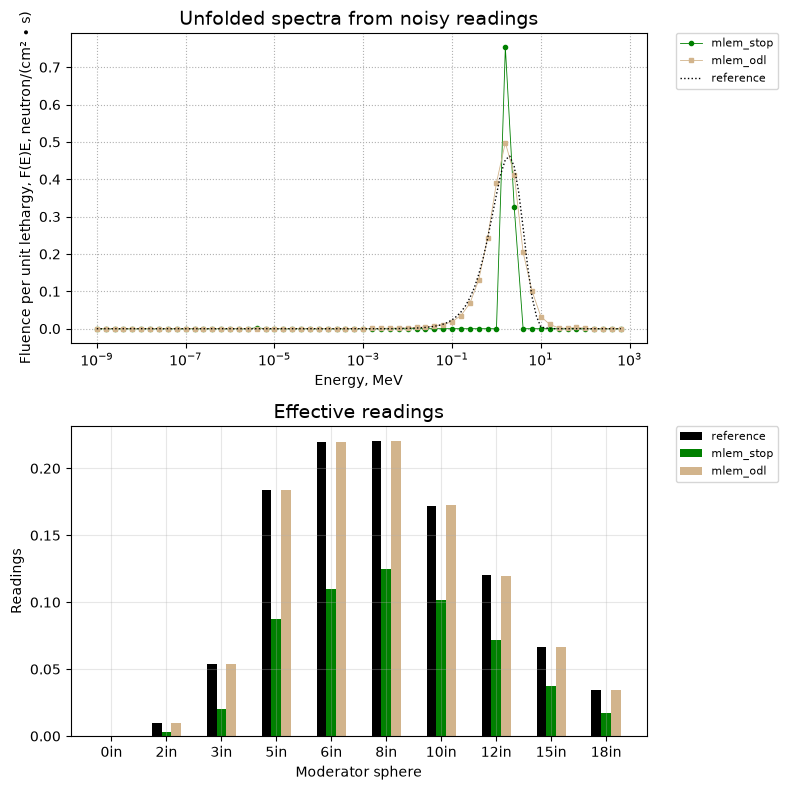

In [5]:
fig, ax = plot_comparison(
    results=results, 
    readings=readings, 
    reference_spectrum=reference_spectrum[['E_MeV','ISO_ref_Cf252']], 
)